# Flood EDA

This notebook combines rainfall, river telemetry/discharge, and flood-event windows into one analysis dataset.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from flood_pipeline import DATA_DIR, OUTPUT_DIR, build_dataset, event_frame, write_eda

pd.set_option('display.max_columns', 80)
OUTPUT_DIR.mkdir(exist_ok=True)

## Data Files

In [2]:
files = pd.DataFrame(
    [{'file': p.name, 'size_mb': round(p.stat().st_size / 1_000_000, 2)} for p in sorted(DATA_DIR.glob('*.csv'))]
)
files

,file,size_mb
0,Assam_2019.csv,0.70
1,Assam_2020.csv,0.58
2,Assam_2021.csv,0.58
3,Assam_2022.csv,0.59
4,Assam_2023.csv,0.59
5,Assam_Riverlevel.csv,11.02
6,Kerala_2019.csv,0.31
7,Kerala_2020.csv,0.30
8,Kerala_2021.csv,0.31
9,Kerala_2022.csv,0.31


## Flood Event Windows

In [3]:
events = event_frame()
events

,state,year,start,end
0,Kerala,2018,2018-06-01,2018-08-19
1,Kerala,2019,2019-08-01,2019-08-31
2,Kerala,2020,2020-06-01,2020-08-18
3,Kerala,2021,2021-10-11,2021-10-26
4,Kerala,2022,2022-08-01,2022-09-10
5,Assam,2019,2019-07-10,2019-08-02
6,Assam,2020,2020-06-02,2020-09-30
7,Assam,2021,2021-06-07,2021-09-02
8,Assam,2022,2022-05-18,2022-07-17
9,Assam,2023,2023-06-16,2023-08-31


## Build Combined Dataset

In [4]:
df = build_dataset(fetch_soil=False)
df.to_csv(OUTPUT_DIR / 'combined_flood_dataset.csv', index=False)
df.shape

(263159, 30)

In [5]:
df.head()

,state,district,date,rainfall_mm,river_measure_type,river_daily_mean,river_daily_max,river_daily_min,river_obs_count,river_is_discharge,is_flood_event,event_year,event_start,event_end,year,month,day_of_year,rainfall_roll3_mean,rainfall_roll3_sum,rainfall_roll7_mean,rainfall_roll7_sum,rainfall_roll14_mean,rainfall_roll14_sum,rainfall_lag1,rainfall_lag3,rainfall_lag7,river_daily_mean_lag1,river_daily_mean_roll3_mean,river_daily_max_lag1,river_daily_max_roll3_mean
0,Assam,BAKSA,2019-01-01,0.0,NaN,NaN,NaN,NaN,NaN,0,0,<NA>,NaT,NaT,2019,1,1,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Assam,BAKSA,2019-01-02,0.0,NaN,NaN,NaN,NaN,NaN,0,0,<NA>,NaT,NaT,2019,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Assam,BAKSA,2019-01-03,0.0,NaN,NaN,NaN,NaN,NaN,0,0,<NA>,NaT,NaT,2019,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Assam,BAKSA,2019-01-04,0.0,NaN,NaN,NaN,NaN,NaN,0,0,<NA>,NaT,NaT,2019,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Assam,BAKSA,2019-01-05,0.0,NaN,NaN,NaN,NaN,NaN,0,0,<NA>,NaT,NaT,2019,1,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


## Coverage and Missing Data

In [6]:
coverage = (
    df.groupby(['state', 'year'], as_index=False)
    .agg(
        rows=('is_flood_event', 'size'),
        flood_event_rows=('is_flood_event', 'sum'),
        districts=('district', 'nunique'),
        avg_rainfall_mm=('rainfall_mm', 'mean'),
        max_rainfall_mm=('rainfall_mm', 'max'),
        avg_river_daily_mean=('river_daily_mean', 'mean'),
    )
)
coverage

,state,year,rows,flood_event_rows,districts,avg_rainfall_mm,max_rainfall_mm,avg_river_daily_mean
0,Assam,2019,12045,792,33,6.024154,199.737006,NaN
1,Assam,2020,10000,3331,33,4.576403,212.470346,NaN
2,Assam,2021,10000,2390,33,4.573154,158.296056,NaN
3,Assam,2022,10000,1671,36,6.948365,245.002897,1.554274
4,Assam,2023,10000,2127,33,5.715529,266.780213,3.292677
5,Kerala,2019,5110,434,14,7.800533,250.733040,NaN
6,Kerala,2020,5124,1106,14,3.335615,91.804079,NaN
7,Kerala,2021,5110,224,14,9.197077,165.969957,9.700453
8,Kerala,2022,5110,574,16,7.846464,130.235189,5.915681
9,Kerala,2023,5110,0,14,6.225345,161.071030,NaN


In [7]:
missing = df.isna().mean().sort_values(ascending=False).to_frame('missing_fraction')
missing.head(25)

,missing_fraction
river_daily_mean_lag1,0.928192
river_daily_max_lag1,0.928192
river_daily_min,0.928180
river_obs_count,0.928180
river_measure_type,0.928180
river_daily_mean,0.928180
river_daily_max,0.928180
river_daily_max_roll3_mean,0.927223
river_daily_mean_roll3_mean,0.927223
event_year,0.875566


## Event vs Non-Event Summary

In [8]:
event_summary = (
    df.groupby(['state', 'is_flood_event'], as_index=False)
    .agg(
        rows=('is_flood_event', 'size'),
        rainfall_mean=('rainfall_mm', 'mean'),
        rainfall_p95=('rainfall_mm', lambda s: s.quantile(0.95)),
        river_mean=('river_daily_mean', 'mean'),
    )
)
event_summary

,state,is_flood_event,rows,rainfall_mean,rainfall_p95,river_mean
0,Assam,0,41734,3.965371,21.363043,2.538873
1,Assam,1,10311,12.142826,45.163968,2.438693
2,Kerala,0,23226,5.896139,28.744231,8.046728
3,Kerala,1,2338,16.643583,61.689227,4.382922
4,Odisha,0,44786,3.014459,16.906088,70.141942
5,Odisha,1,6164,8.977758,36.030224,430.853440
6,Uttar Pradesh,0,120667,1.877703,10.883028,73.546338
7,Uttar Pradesh,1,13933,5.535861,24.676849,79.985795


## Visual EDA

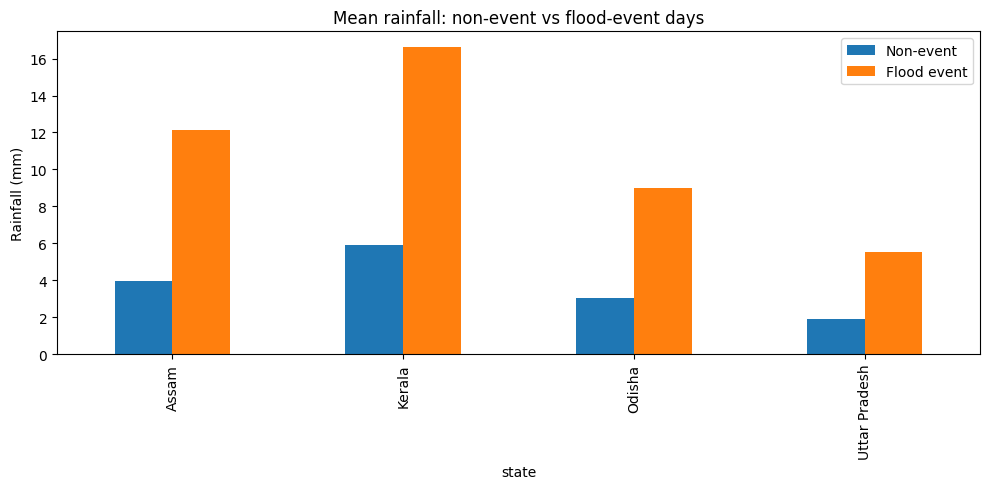

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = df.groupby(['state', 'is_flood_event'])['rainfall_mm'].mean().unstack()
plot_data.plot(kind='bar', ax=ax)
ax.set_title('Mean rainfall: non-event vs flood-event days')
ax.set_ylabel('Rainfall (mm)')
ax.legend(['Non-event', 'Flood event'])
plt.tight_layout()

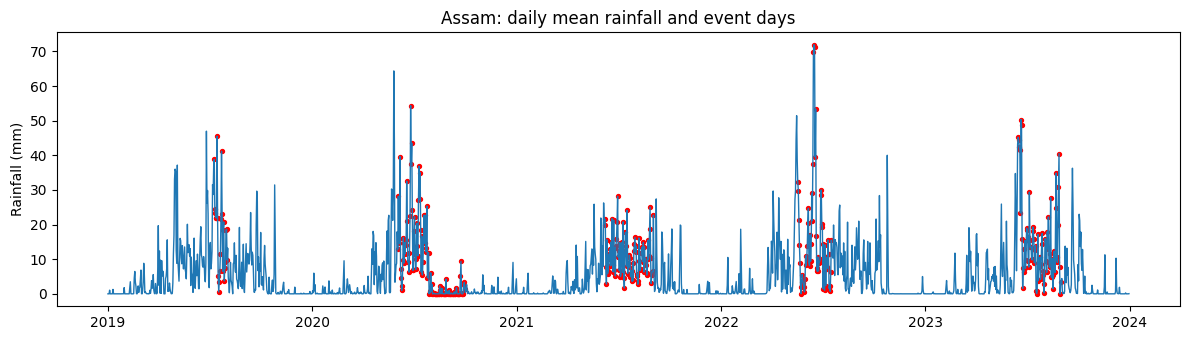

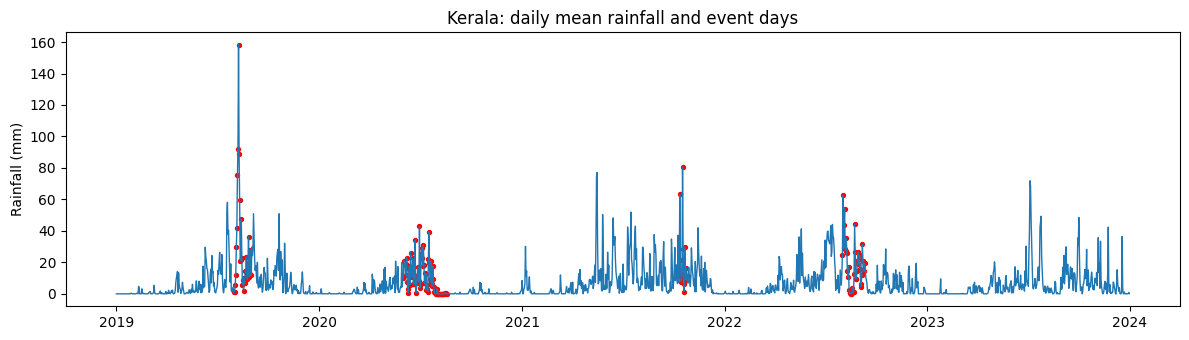

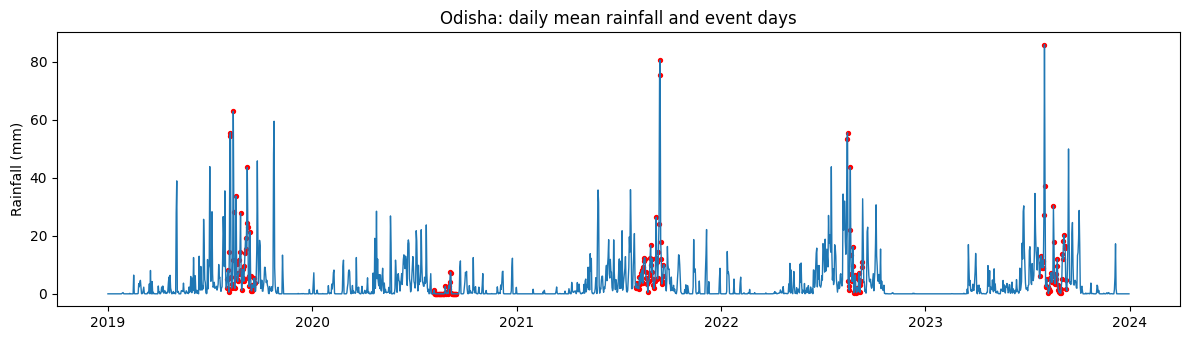

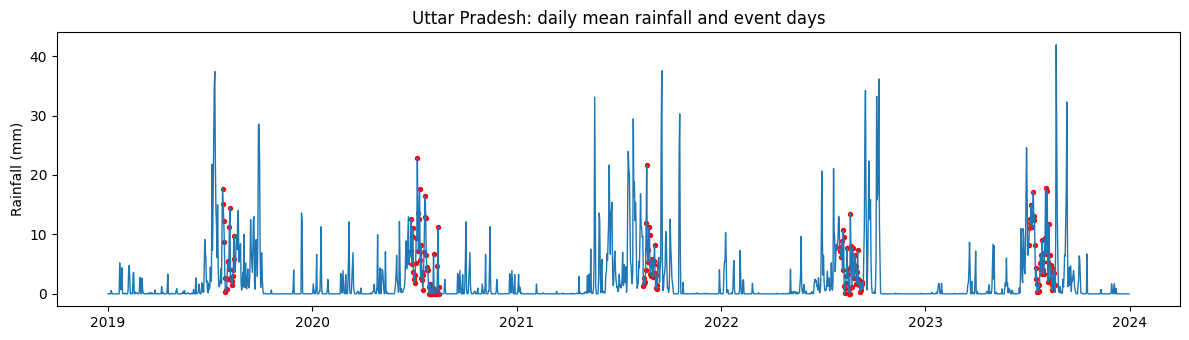

In [10]:
for state, state_df in df.groupby('state'):
    daily = (
        state_df.groupby('date', as_index=False)
        .agg(rainfall_mm=('rainfall_mm', 'mean'), is_flood_event=('is_flood_event', 'max'))
        .sort_values('date')
    )
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(daily['date'], daily['rainfall_mm'], linewidth=1.0)
    flood_days = daily[daily['is_flood_event'] == 1]
    ax.scatter(flood_days['date'], flood_days['rainfall_mm'], s=8, color='red')
    ax.set_title(f'{state}: daily mean rainfall and event days')
    ax.set_ylabel('Rainfall (mm)')
    plt.tight_layout()
    plt.show()

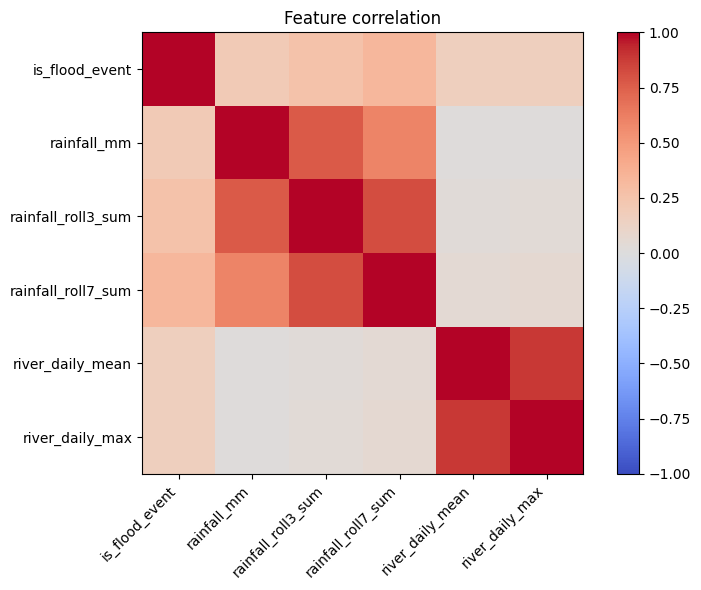

In [11]:
corr_cols = [
    'is_flood_event', 'rainfall_mm', 'rainfall_roll3_sum', 'rainfall_roll7_sum',
    'river_daily_mean', 'river_daily_max'
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)), corr.index)
fig.colorbar(image, ax=ax)
ax.set_title('Feature correlation')
plt.tight_layout()

## Save EDA Artifacts

In [ ]:
write_eda(df)
print(f'Saved combined dataset and EDA artifacts under {OUTPUT_DIR}')